# Shoe Size Prediction(Machine Learning)

## Install ,Import and Setup

In [1]:
! pip install scikit-learn


  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.2 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.2 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 10.8 MB/s  0:00:01
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------------------------

In [7]:
#eda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#filter warning 
import warnings as w
w.filterwarnings('ignore')


#set theme for plots
sns.set_style('darkgrid')

#Import Machine Learning Functins from different sub-Package
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#time stamp
import time
print(f"Last Update:{time.asctime()}")

Last Update:Mon Aug  3 10:04:18 2026


In [8]:
#Load Dataset
df=pd.read_csv('Dataset/shoe_size_dataset.csv')
df.head(2)

,height_cm,weight_kg,gender,shoe_size_us
0,177.4,96.8,Male,10.0
1,167.7,56.8,Female,6.0


## Exploratory Data Analysis

In [9]:
df.shape

(500, 4)

In [12]:
df.dtypes

height_cm       float64
weight_kg       float64
gender              str
shoe_size_us    float64
dtype: object

In [13]:
#complete Info
df.info

<bound method DataFrame.info of      height_cm  weight_kg  gender  shoe_size_us
0        177.4       96.8    Male          10.0
1        167.7       56.8  Female           6.0
2        156.6       66.4  Female           4.0
3        154.1       78.5  Female           4.0
4        183.3       73.3    Male           9.5
..         ...        ...     ...           ...
495      170.3       88.4    Male           9.5
496      158.4       78.4  Female           4.0
497      179.7       73.1    Male           8.5
498      174.9       56.5  Female           6.0
499      166.5       64.7  Female           5.5

[500 rows x 4 columns]>

In [14]:
#Describe
df.describe()

,height_cm,weight_kg,shoe_size_us
count,500.000000,500.000000,500.000000
mean,168.490000,70.088400,6.697000
std,8.654966,12.667843,2.045987
min,146.700000,35.900000,4.000000
25%,162.275000,61.100000,4.875000
50%,168.050000,68.950000,6.500000
75%,174.800000,78.700000,8.500000
max,196.600000,104.300000,12.000000


In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
height_cm,500.0,NaN,NaN,NaN,168.49,8.654966,146.7,162.275,168.05,174.8,196.6
weight_kg,500.0,NaN,NaN,NaN,70.0884,12.667843,35.9,61.1,68.95,78.7,104.3
gender,500,2,Female,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shoe_size_us,500.0,NaN,NaN,NaN,6.697,2.045987,4.0,4.875,6.5,8.5,12.0


In [16]:
df.gender.value_counts()

gender
Female    259
Male      241
Name: count, dtype: int64

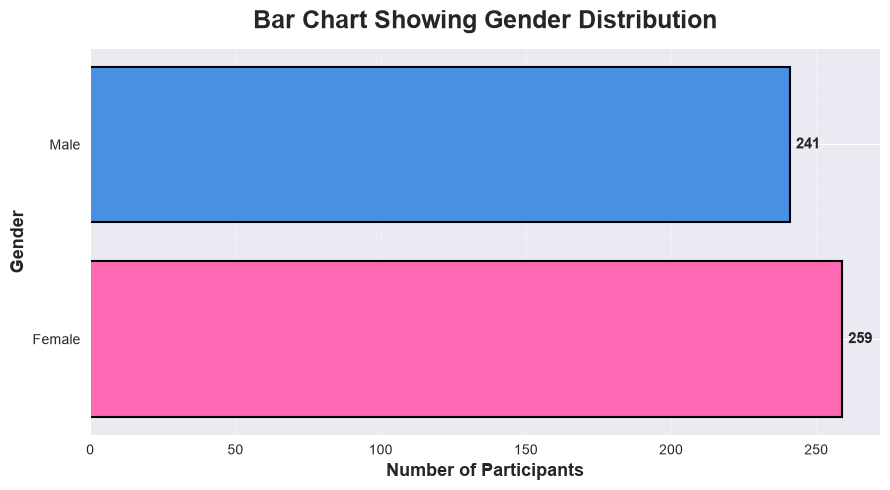

In [25]:
#Bar Chart Showing Gender Distribution

# Count gender occurrences
gender_counts = df['gender'].value_counts()

# Create figure
plt.figure(figsize=(9, 5))

# Custom colors
colors = ['#FF69B4', '#4A90E2']   # Pink and Blue

# Horizontal bar chart
bars = plt.barh(
    gender_counts.index,
    gender_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Titles and labels
plt.title(
    "Bar Chart Showing Gender Distribution",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Number of Participants",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Gender",
    fontsize=13,
    fontweight='bold'
)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Plots/Bar_Chart_showing_Gender_Distribution.png')
plt.show()


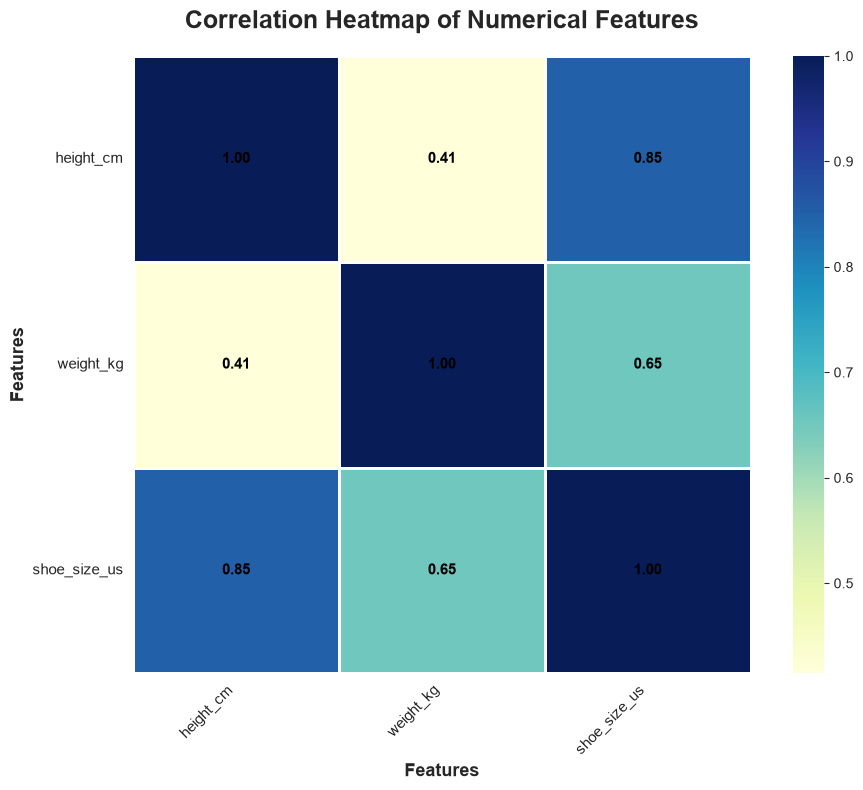

In [24]:
#Correlation Heatmap

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Set figure size
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                 # Display correlation values
    cmap="YlGnBu",              # Color map
    fmt=".2f",                  # Show values up to 2 decimal places
    linewidths=1,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={
        "size": 11,
        "weight": "bold",
        "color": "black"
    }
)

# Title
plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Features",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=13,
    fontweight="bold"
)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Adjust layout
plt.tight_layout()
plt.savefig("

# Display the plot
plt.show()

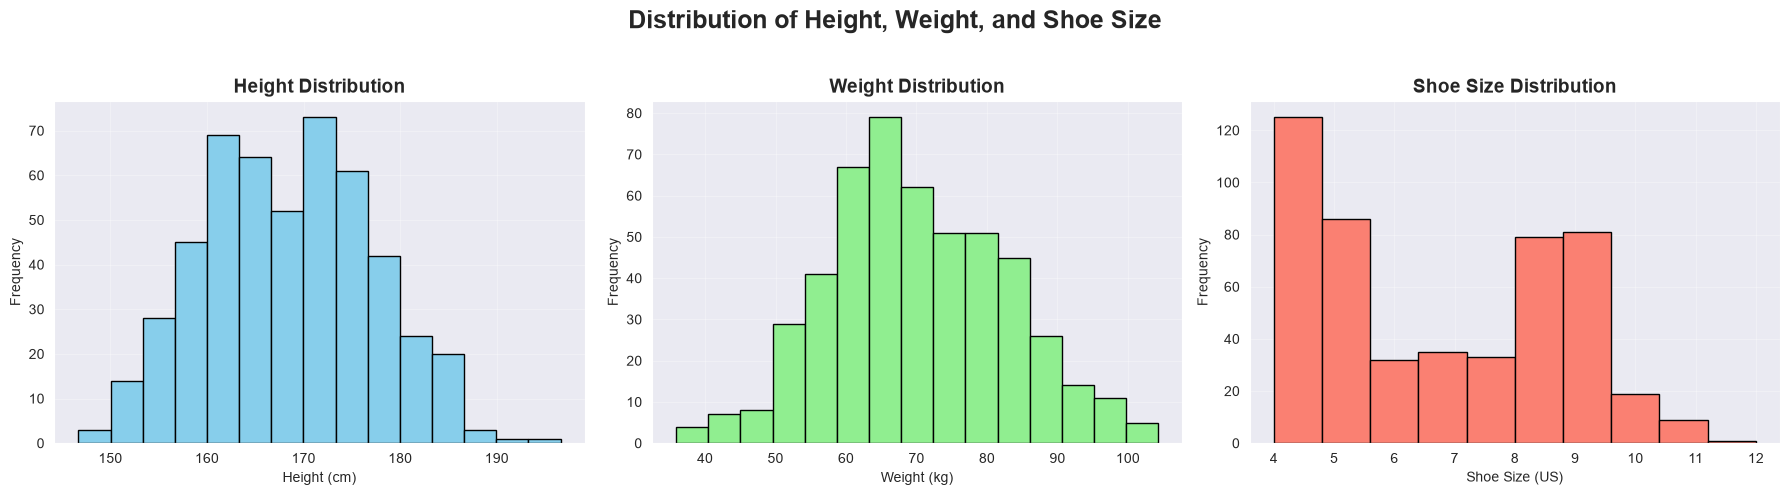

In [32]:
# SubPlots
#Height_CM
#Weight_Kg
#shoe_size_us

# Create 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------
# Height Distribution
# -------------------------------
axes[0].hist(
    df["height_cm"],
    bins=15,
    color="skyblue",
    edgecolor="black"
)
axes[0].set_title("Height Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

# -------------------------------
# Weight Distribution
# -------------------------------
axes[1].hist(
    df["weight_kg"],
    bins=15,
    color="lightgreen",
    edgecolor="black"
)
axes[1].set_title("Weight Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

# -------------------------------
# Shoe Size Distribution
# -------------------------------
axes[2].hist(
    df["shoe_size_us"],
    bins=10,
    color="salmon",
    edgecolor="black"
)
axes[2].set_title("Shoe Size Distribution", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Shoe Size (US)")
axes[2].set_ylabel("Frequency")
axes[2].grid(alpha=0.3)

# Overall title
plt.suptitle(
    "Distribution of Height, Weight, and Shoe Size",
    fontsize=18,
    fontweight="bold"
)

# Adjust spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Plots/Subplots.png')

# Show plot
plt.show()

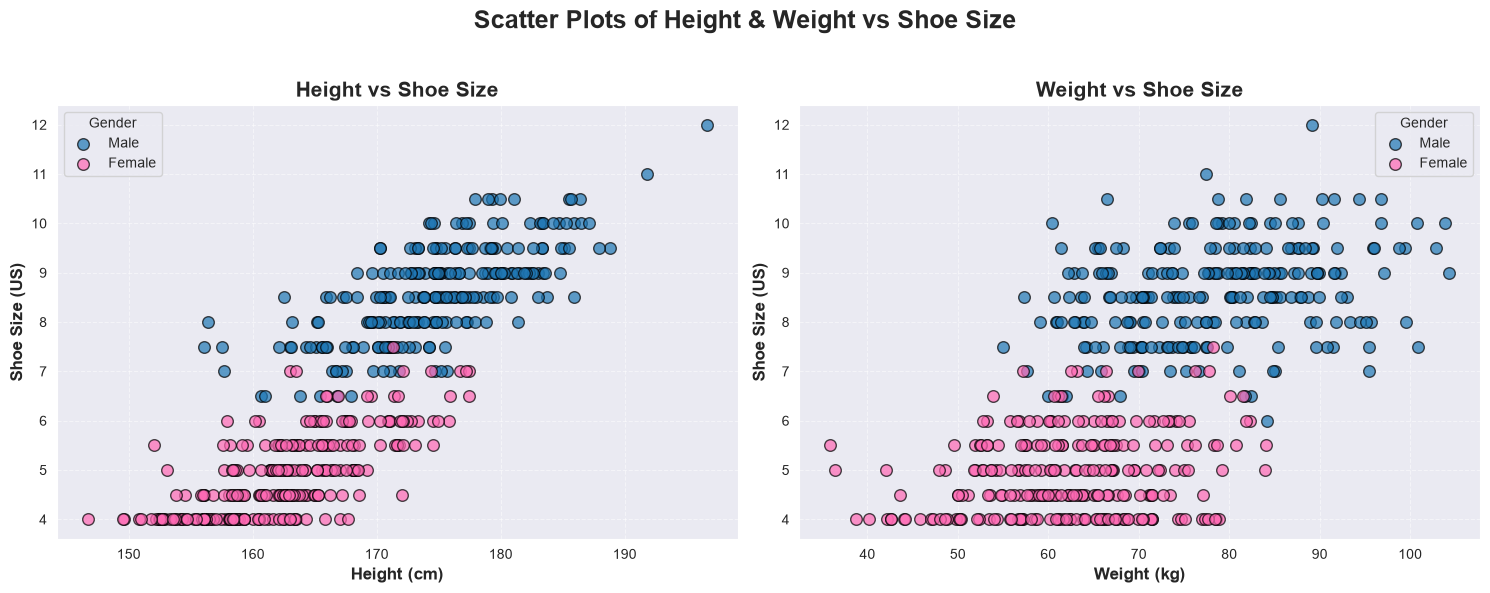

In [37]:
#subplot (1,2)
#1.scatter plot(height vs shoe size) (color shows gender)
#2.Sctter plot (weight sv shoe size)(color show gender)


# Define colors for each gender
colors = {"Male": "#1f77b4", "Female": "#ff69b4"}

# Create 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------------------------
# 1. Scatter Plot: Height vs Shoe Size
# -----------------------------------------
for gender in df["gender"].unique():
    subset = df[df["gender"] == gender]
    axes[0].scatter(
        subset["height_cm"],
        subset["shoe_size_us"],
        label=gender,
        color=colors[gender],
        s=70,
        alpha=0.7,
        edgecolors="black"
    )

axes[0].set_title("Height vs Shoe Size", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Height (cm)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Shoe Size (US)", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(title="Gender")

# -----------------------------------------
# 2. Scatter Plot: Weight vs Shoe Size
# -----------------------------------------
for gender in df["gender"].unique():
    subset = df[df["gender"] == gender]
    axes[1].scatter(
        subset["weight_kg"],
        subset["shoe_size_us"],
        label=gender,
        color=colors[gender],
        s=70,
        alpha=0.7,
        edgecolors="black"
    )

axes[1].set_title("Weight vs Shoe Size", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Weight (kg)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Shoe Size (US)", fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(title="Gender")

# Overall Title
plt.suptitle(
    "Scatter Plots of Height & Weight vs Shoe Size",
    fontsize=18,
    fontweight="bold"
)

# Adjust spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Plots/Scatter_Chart.png')

# Show plot
plt.show()

# Data Processing 

## Label Encoding

In [38]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])


### Feature and Target Split 

In [43]:
X=df.drop('shoe_size_us',axis=1)
y=df['shoe_size_us']

### Train Test Split

In [79]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


### Scalling 

In [52]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [53]:
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler
)

In [54]:
# Sample Dataset

data = {
    "Height_CM": [150,155,160,165,170,175,180,185,190,195],
    "Weight_Kg": [45,50,55,60,65,70,75,80,85,90],
    "Shoe_Size_US": [5,6,7,8,8,9,10,11,12,13]
}

df = pd.DataFrame(data)

print("Original Dataset")
display(df)

Original Dataset


,Height_CM,Weight_Kg,Shoe_Size_US
0,150,45,5
1,155,50,6
2,160,55,7
3,165,60,8
4,170,65,8
5,175,70,9
6,180,75,10
7,185,80,11
8,190,85,12
9,195,90,13


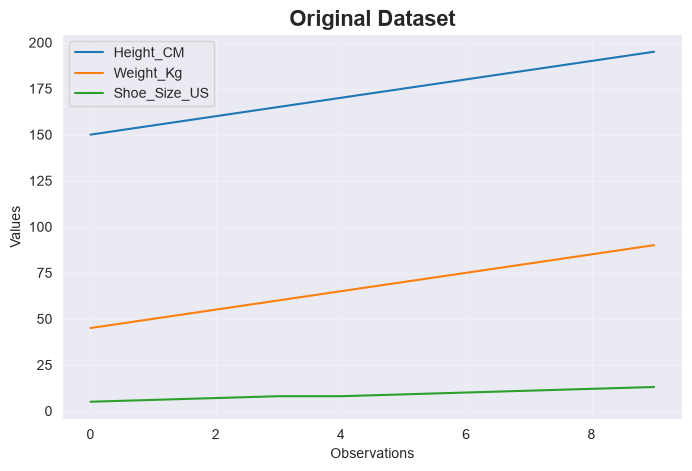

In [55]:
plt.figure(figsize=(8,5))

plt.plot(df)

plt.title("Original Dataset",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Observations")
plt.ylabel("Values")

plt.legend(df.columns)

plt.grid(alpha=0.3)

plt.show()

In [56]:
scaler = MinMaxScaler()

minmax_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Min-Max Scaled Data")
display(minmax_df)

Min-Max Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,0.000000,0.000000,0.000
1,0.111111,0.111111,0.125
2,0.222222,0.222222,0.250
3,0.333333,0.333333,0.375
4,0.444444,0.444444,0.375
5,0.555556,0.555556,0.500
6,0.666667,0.666667,0.625
7,0.777778,0.777778,0.750
8,0.888889,0.888889,0.875
9,1.000000,1.000000,1.000


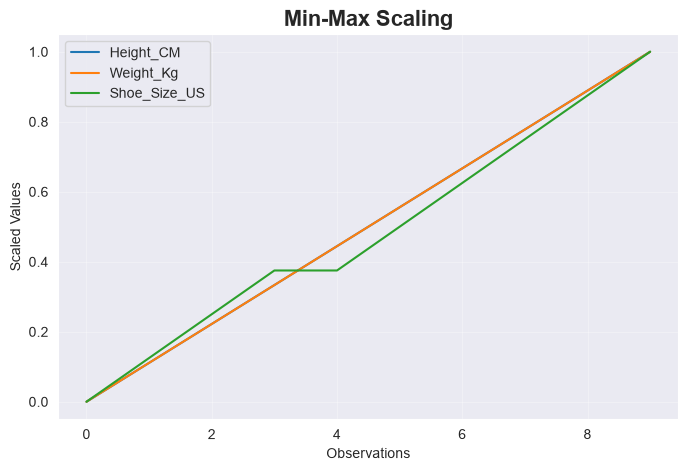

In [57]:
plt.figure(figsize=(8,5))

plt.plot(minmax_df)

plt.title("Min-Max Scaling",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Observations")
plt.ylabel("Scaled Values")

plt.legend(minmax_df.columns)

plt.grid(alpha=0.3)

plt.show()

In [58]:
scaler = StandardScaler()

standard_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Standard Scaled Data")
display(standard_df)

Standard Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,-1.566699,-1.566699,-1.580360
1,-1.218544,-1.218544,-1.175139
2,-0.870388,-0.870388,-0.769919
3,-0.522233,-0.522233,-0.364698
4,-0.174078,-0.174078,-0.364698
5,0.174078,0.174078,0.040522
6,0.522233,0.522233,0.445742
7,0.870388,0.870388,0.850963
8,1.218544,1.218544,1.256183
9,1.566699,1.566699,1.661404


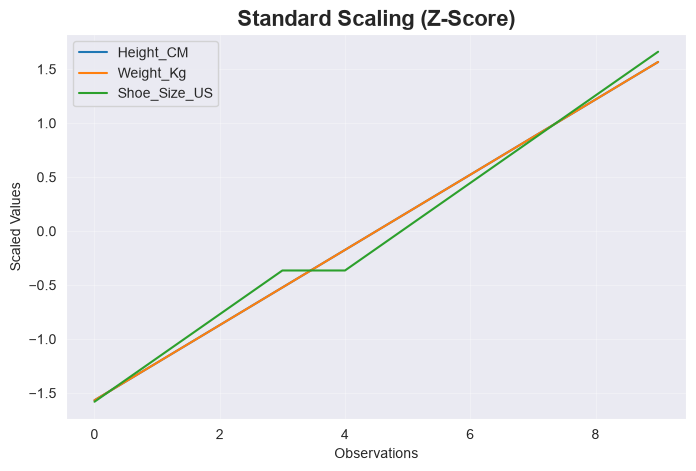

In [59]:
plt.figure(figsize=(8,5))

plt.plot(standard_df)

plt.title("Standard Scaling (Z-Score)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Observations")
plt.ylabel("Scaled Values")

plt.legend(standard_df.columns)

plt.grid(alpha=0.3)

plt.show()

In [60]:
scaler = RobustScaler()

robust_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Robust Scaled Data")
display(robust_df)

Robust Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,-1.000000,-1.000000,-1.000000
1,-0.777778,-0.777778,-0.714286
2,-0.555556,-0.555556,-0.428571
3,-0.333333,-0.333333,-0.142857
4,-0.111111,-0.111111,-0.142857
5,0.111111,0.111111,0.142857
6,0.333333,0.333333,0.428571
7,0.555556,0.555556,0.714286
8,0.777778,0.777778,1.000000
9,1.000000,1.000000,1.285714


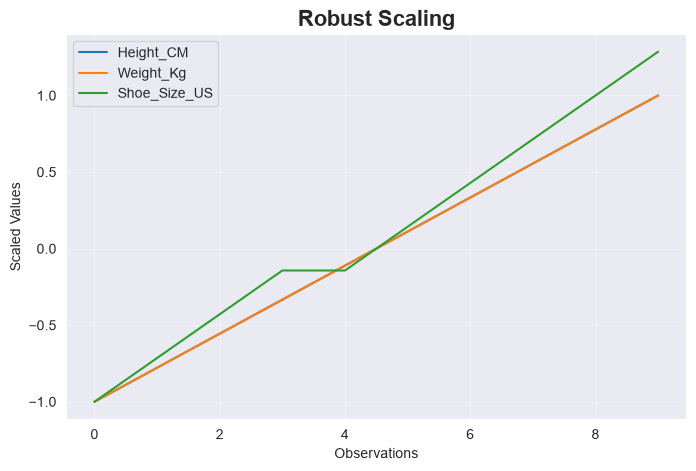

In [61]:
plt.figure(figsize=(8,5))

plt.plot(robust_df)

plt.title("Robust Scaling",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Observations")
plt.ylabel("Scaled Values")

plt.legend(robust_df.columns)

plt.grid(alpha=0.3)

plt.show()

In [62]:
scaler = MaxAbsScaler()

maxabs_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Max Absolute Scaled Data")
display(maxabs_df)

Max Absolute Scaled Data


,Height_CM,Weight_Kg,Shoe_Size_US
0,0.769231,0.500000,0.384615
1,0.794872,0.555556,0.461538
2,0.820513,0.611111,0.538462
3,0.846154,0.666667,0.615385
4,0.871795,0.722222,0.615385
5,0.897436,0.777778,0.692308
6,0.923077,0.833333,0.769231
7,0.948718,0.888889,0.846154
8,0.974359,0.944444,0.923077
9,1.000000,1.000000,1.000000


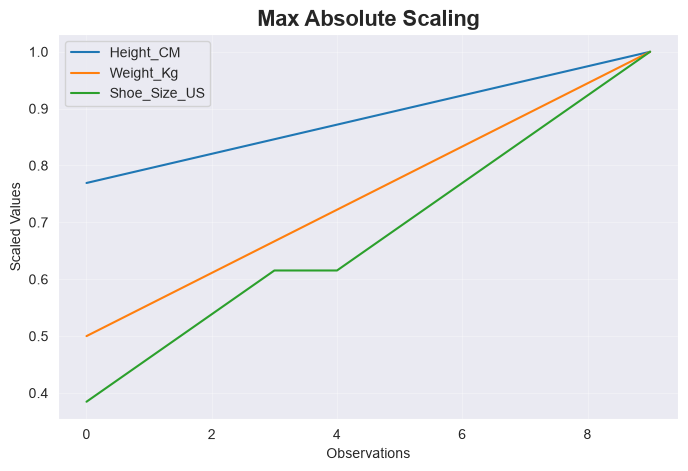

In [63]:
plt.figure(figsize=(8,5))

plt.plot(maxabs_df)

plt.title("Max Absolute Scaling",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Observations")
plt.ylabel("Scaled Values")

plt.legend(maxabs_df.columns)

plt.grid(alpha=0.3)

plt.show()

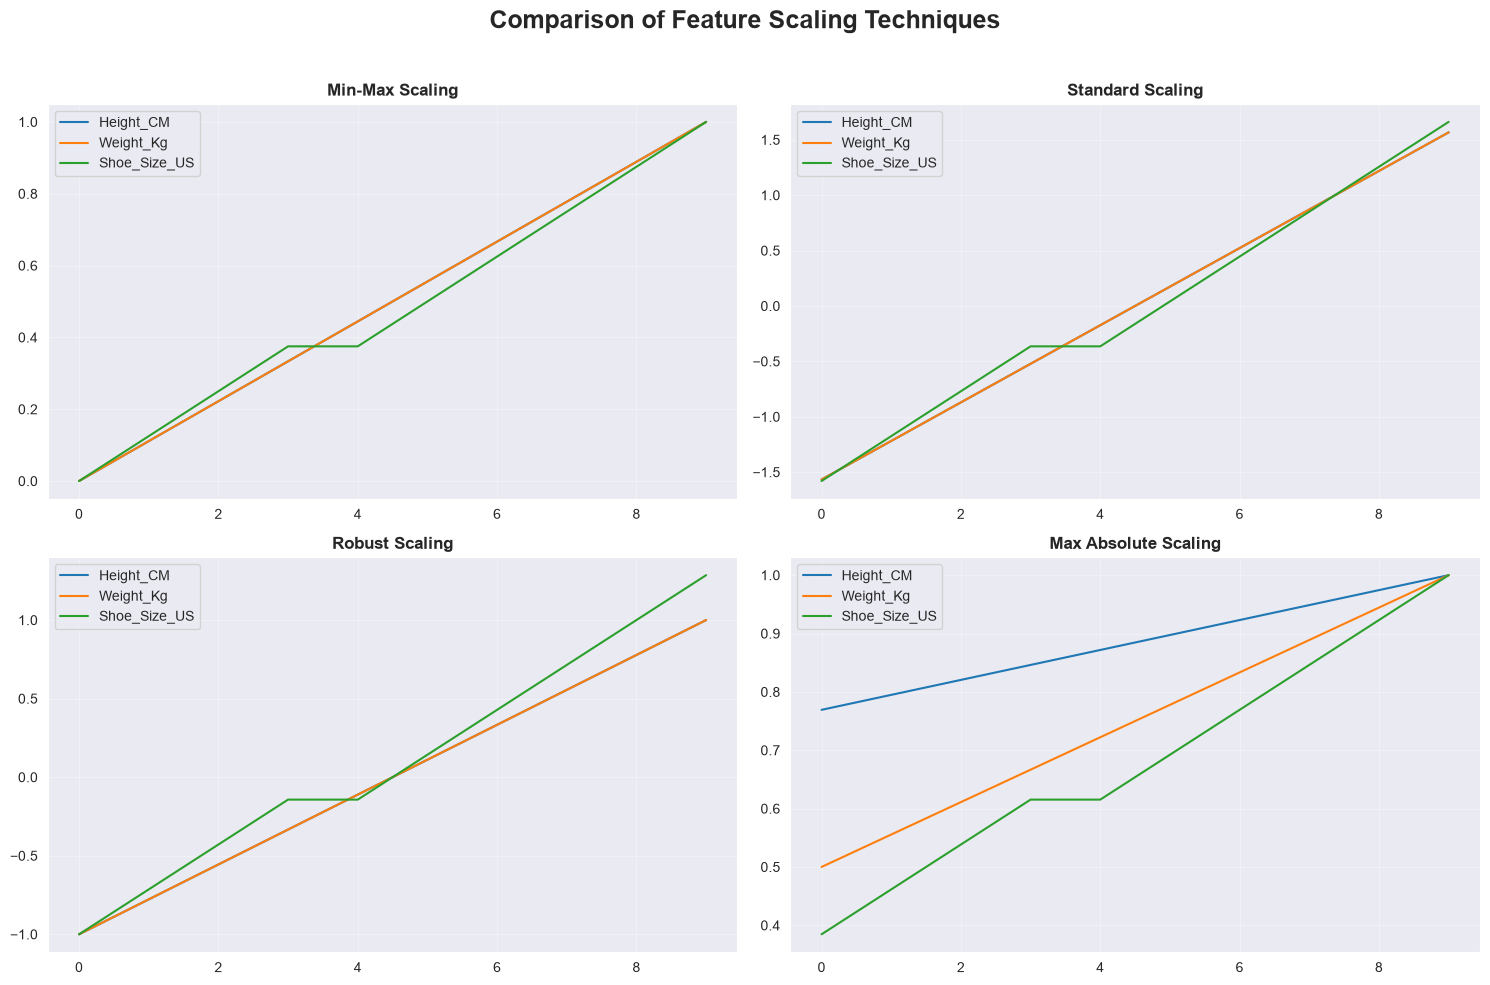

In [64]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Min-Max
axes[0,0].plot(minmax_df)
axes[0,0].set_title("Min-Max Scaling", fontweight="bold")
axes[0,0].legend(minmax_df.columns)
axes[0,0].grid(alpha=0.3)

# Standard
axes[0,1].plot(standard_df)
axes[0,1].set_title("Standard Scaling", fontweight="bold")
axes[0,1].legend(standard_df.columns)
axes[0,1].grid(alpha=0.3)

# Robust
axes[1,0].plot(robust_df)
axes[1,0].set_title("Robust Scaling", fontweight="bold")
axes[1,0].legend(robust_df.columns)
axes[1,0].grid(alpha=0.3)

# Max Absolute
axes[1,1].plot(maxabs_df)
axes[1,1].set_title("Max Absolute Scaling", fontweight="bold")
axes[1,1].legend(maxabs_df.columns)
axes[1,1].grid(alpha=0.3)

plt.suptitle(
    "Comparison of Feature Scaling Techniques",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

## Model Training

In [66]:
lg=LinearRegression()


In [67]:
#train model on data
lg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.9 ,0.35,1.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.724
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[29.4 ,15.61, 9.59]"


## Prediction 

In [72]:
y_pred=lg.predict(X_test)

In [73]:
y_test[:10],y_pred[:10]

(419     4.0
 188     6.5
 209     7.5
 426    10.5
 300     9.5
 255     5.5
 81      5.0
 305     6.0
 377     8.0
 308     4.5
 Name: shoe_size_us, dtype: float64,
 array([ 4.69997338,  6.60588574,  8.41621836,  9.77132319, 10.30610077,
         4.7823678 ,  4.96035078,  6.26691082,  8.99896334,  4.74201795]))

In [74]:
#comparison _df=


## Metrices

In [77]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2s=r2_score(y_test,y_pred)


In [80]:
mae,mse,r2s

(0.5490697769323358, 0.46053546310286536, 0.8818200459075508)